# 02. Principal Stratification

Many applied causal questions involve post-treatment variables:

- Did treatment work among people who actually took it?
- What is the effect among people who would survive under either treatment?
- Did a feature help users who would engage with it?
- Is a surrogate endpoint a meaningful way to compare treatments?

The trap is that post-treatment groups are affected by treatment. If we condition on observed treatment received, observed survival, observed engagement, or observed adherence, we may compare different kinds of units.

Principal stratification is a framework for defining causal effects within groups determined by **joint potential values** of a post-treatment variable. It gives us a careful way to talk about compliance types, always-survivors, protected units, and other latent response types.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain why observed post-treatment groups are not ordinary covariates.
- Define principal strata using potential values of an intermediate variable.
- Interpret compliers, always-takers, never-takers, and defiers in noncompliance settings.
- Estimate the complier average causal effect using the Wald instrumental variables estimand.
- Explain truncation by death and the survivor average causal effect.
- Use monotonicity and bounds to reason about effects among always-survivors.
- Describe principal scores and why individual principal strata are usually latent.
- Write a careful principal-stratification readout for decision-makers.


## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term):
    """Compute regression effect for the principal stratification example.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

The notebook simulates studies where assignment, treatment receipt, and outcome observability do not line up cleanly. The units can be program participants, patients, students, or customers. Treatment assignment is observed, actual receipt may differ from assignment, and in some sections the outcome exists only for units in certain post-assignment states. The examples include noncompliance and truncation-like settings.

Synthetic data is used because principal strata are usually latent. In real data, we observe assignment, receipt, and outcomes, but we do not observe whether a unit would comply under every assignment condition or whether an outcome would exist under every treatment condition. The simulation makes those hidden strata visible for teaching. That lets the notebook explain complier effects, always-takers, never-takers, protected units, survivor effects, and why naive comparisons among observed outcome cases can answer the wrong question.


## 2. The Post-Treatment Conditioning Problem

Suppose $Z$ is randomized assignment, $S$ is a post-treatment variable, and $Y$ is the outcome.

Examples of $S$:

- actual treatment received,
- survival,
- engagement,
- adherence,
- passing a screening step,
- being observed at follow-up.

The common mistake is to compare:

$$
E[Y \mid Z=1, S=1] - E[Y \mid Z=0, S=1]
$$

This compares units who **ended up** with $S=1$ under different assignments. But those observed groups may contain different latent types.


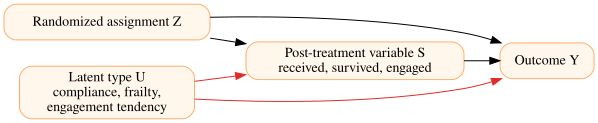

In [2]:
dot = Digraph("post_treatment_conditioning", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#fff7ec", color="#fdae6b")

dot.node("Z", "Randomized assignment Z")
dot.node("S", "Post-treatment variable S\nreceived, survived, engaged")
dot.node("Y", "Outcome Y")
dot.node("U", "Latent type U\ncompliance, frailty,\nengagement tendency")

dot.edge("Z", "S")
dot.edge("Z", "Y")
dot.edge("S", "Y")
dot.edge("U", "S", color="#de2d26")
dot.edge("U", "Y", color="#de2d26")

dot


Conditioning on observed $S$ can open selection problems because $S$ is downstream of treatment. Principal stratification avoids this by defining strata using potential values of $S$ under each treatment level.

Frangakis and Rubin (2002) introduced principal stratification as a general framework for causal effects adjusted for post-treatment variables. Their key point is that principal strata are defined before assignment in the sense that each unit's pair of potential post-treatment values is fixed, even though only one value is observed.


## 3. Principal Strata

Let $S_i(1)$ be the value of the post-treatment variable if unit $i$ is assigned treatment, and $S_i(0)$ be the value if assigned control.

The principal stratum is:

$$
G_i = (S_i(0), S_i(1))
$$

For binary $S$, there are four possible strata:


| S(0) | S(1) | name | interpretation |
|---|---|---|---|
| 0 | 0 | Never | S would be 0 under either assignment. |
| 0 | 1 | Induced / protected / complier | Treatment changes S from 0 to 1. |
| 1 | 0 | Harmed / defier | Treatment changes S from 1 to 0. |
| 1 | 1 | Always | S would be 1 under either assignment. |


The crucial property is that $G_i$ is not caused by the actual assignment $Z_i$. It is a latent pre-assignment type. That means we can define causal effects within principal strata:

$$
\tau_g = E[Y_i(1) - Y_i(0) \mid G_i=g]
$$

The difficulty is that $G_i$ is usually only partially observed.


## 4. Example 1: Noncompliance

Noncompliance is the most familiar principal-stratification example.

Let:

- $Z$ = randomized assignment or encouragement,
- $D$ = actual treatment received,
- $D(1)$ = treatment received if assigned treatment,
- $D(0)$ = treatment received if assigned control.

Principal strata are compliance types:


| D(0) | D(1) | type | meaning |
|---|---|---|---|
| 0 | 0 | Never-taker | Never takes treatment. |
| 0 | 1 | Complier | Takes treatment if assigned, does not if control. |
| 1 | 0 | Defier | Does the opposite of assignment. |
| 1 | 1 | Always-taker | Always takes treatment. |


The instrumental variables estimand identifies the complier average causal effect under standard assumptions:

- random assignment of $Z$,
- relevance: assignment changes treatment received,
- exclusion: assignment affects the outcome only through treatment received,
- monotonicity: no defiers,
- SUTVA and well-defined treatment.

Angrist, Imbens, and Rubin (1996) formalized this interpretation of the instrumental variables estimand as a local average treatment effect for compliers.


## 5. Simulating Noncompliance

We simulate a randomized encouragement where assignment changes actual treatment for compliers. Always-takers and never-takers are unaffected by assignment.


In [5]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_noncompliance(seed=2027, n=14000):
    """Simulate the noncompliance data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n`: number of simulated units or records to generate for the teaching example.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    age = np.clip(rng.normal(42 + 5 * x, 10, size=n), 18, 75)
    risk = np.clip(rng.beta(2 + 0.8 * (x > 0), 4, size=n), 0.02, 0.95)
    z = rng.binomial(1, 0.5, size=n)

    p_always = expit(-2.00 + 0.75 * x + 0.70 * risk)
    p_never = expit(-1.15 - 0.85 * x - 0.30 * risk)
    raw = np.vstack([p_never, 1.0 - p_always - p_never, p_always]).T
    raw[:, 1] = np.clip(raw[:, 1], 0.05, None)
    probs = raw / raw.sum(axis=1, keepdims=True)

    u = rng.uniform(size=n)
    cum = probs.cumsum(axis=1)
    strata = np.where(u < cum[:, 0], "Never-taker", np.where(u < cum[:, 1], "Complier", "Always-taker"))

    d0 = np.where(strata == "Always-taker", 1, 0)
    d1 = np.where(strata == "Never-taker", 0, 1)
    d = np.where(z == 1, d1, d0)

    base_y = 52 + 4.0 * x + 8.0 * risk + 0.08 * age + rng.normal(0, 5.0, size=n)
    tau = np.select(
        [strata == "Complier", strata == "Always-taker", strata == "Never-taker"],
        [7.0 + 1.5 * risk, 3.0 + 1.0 * risk, 1.0 + 0.5 * risk],
    )
    y0 = base_y
    y1 = base_y + tau
    y = np.where(d == 1, y1, y0)

    return pd.DataFrame(
        {
            "x": x,
            "age": age,
            "risk": risk,
            "assignment": z,
            "received": d,
            "d0": d0,
            "d1": d1,
            "stratum": strata,
            "y0": y0,
            "y1": y1,
            "true_effect": tau,
            "outcome": y,
        }
    )


df_nc = simulate_noncompliance()
df_nc.head()


,x,age,risk,assignment,received,d0,d1,stratum,y0,y1,true_effect,outcome
0,0.111,48.980,0.626,0,0,0,1,Complier,60.646,68.585,7.939,60.646
1,-0.084,27.682,0.249,0,1,1,1,Always-taker,52.385,55.633,3.249,55.633
2,-0.804,41.589,0.619,1,1,0,1,Complier,61.462,69.390,7.928,69.390
3,-2.152,30.049,0.485,1,0,0,0,Never-taker,39.336,40.579,1.243,39.336
4,1.212,36.345,0.484,0,0,0,1,Complier,65.922,73.647,7.725,65.922


Because this is a simulation, we can see the true principal strata. In real data, we observe only assignment and received treatment.

latent strata help define effects for groups created by post-assignment behavior while avoiding naive conditioning on the observed post-treatment variable.

In [6]:
observed_table = pd.crosstab(
    [df_nc["assignment"], df_nc["received"]],
    df_nc["stratum"],
    normalize="index",
).round(3)

observed_table


stratum              Always-taker  Complier  Never-taker
assignment received                                     
0          0                0.000     0.705        0.295
           1                1.000     0.000        0.000
1          0                0.000     0.000        1.000
           1                0.233     0.767        0.000

Some observed cells reveal strata:

- assigned control and received treatment: always-takers,
- assigned treatment and did not receive treatment: never-takers.

Other observed cells are mixtures:

- assigned treatment and received treatment: compliers plus always-takers,
- assigned control and did not receive treatment: compliers plus never-takers.


In [7]:
assignment_summary = (
    df_nc.groupby("assignment")
    .agg(
        n=("outcome", "size"),
        treatment_received=("received", "mean"),
        outcome=("outcome", "mean"),
    )
    .rename(index={0: "Control assignment", 1: "Treatment assignment"})
)
assignment_summary.loc["Difference"] = assignment_summary.loc["Treatment assignment"] - assignment_summary.loc["Control assignment"]
assignment_summary


,n,treatment_received,outcome
assignment,,,
Control assignment,"6,943.000",0.178,59.131
Treatment assignment,"7,057.000",0.745,63.261
Difference,114.000,0.567,4.130


This result deserves a close look because it turns the method into something we can audit. Principal strata help define effects for groups created by post-assignment behavior without conditioning naively on that behavior.

In [8]:
itt_y = df_nc.loc[df_nc["assignment"] == 1, "outcome"].mean() - df_nc.loc[df_nc["assignment"] == 0, "outcome"].mean()
first_stage = df_nc.loc[df_nc["assignment"] == 1, "received"].mean() - df_nc.loc[df_nc["assignment"] == 0, "received"].mean()
wald_late = itt_y / first_stage
true_cace = df_nc.loc[df_nc["stratum"] == "Complier", "true_effect"].mean()
naive_received_diff = df_nc.loc[df_nc["received"] == 1, "outcome"].mean() - df_nc.loc[df_nc["received"] == 0, "outcome"].mean()

late_readout = pd.Series(
    {
        "ITT on outcome": itt_y,
        "First stage": first_stage,
        "Wald LATE / CACE": wald_late,
        "True complier effect": true_cace,
        "Naive received-vs-not difference": naive_received_diff,
    }
)

late_readout


ITT on outcome                     4.130
First stage                        0.567
Wald LATE / CACE                   7.281
True complier effect               7.559
Naive received-vs-not difference   8.210
dtype: float64

The received-versus-not comparison is not the complier causal effect. It compares units who select into treatment receipt under different latent types.

The Wald estimand uses randomized assignment to isolate the effect among compliers:

$$
CACE =
\frac{E[Y \mid Z=1] - E[Y \mid Z=0]}
{E[D \mid Z=1] - E[D \mid Z=0]}
$$


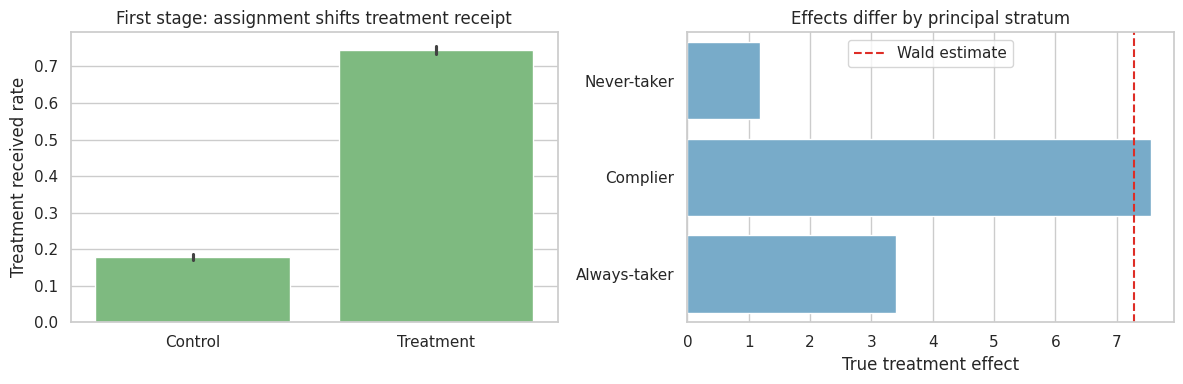

In [9]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=df_nc,
    x="assignment",
    y="received",
    color="#74c476",
    ax=axes[0],
)
axes[0].set_title("First stage: assignment shifts treatment receipt")
axes[0].set_xticklabels(["Control", "Treatment"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Treatment received rate")

true_by_stratum = (
    df_nc.groupby("stratum")["true_effect"]
    .mean()
    .reindex(["Never-taker", "Complier", "Always-taker"])
    .reset_index()
)
sns.barplot(
    data=true_by_stratum,
    x="true_effect",
    y="stratum",
    color="#6baed6",
    ax=axes[1],
)
axes[1].axvline(wald_late, color="#de2d26", linestyle="--", label="Wald estimate")
axes[1].set_title("Effects differ by principal stratum")
axes[1].set_xlabel("True treatment effect")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()


The IV estimate is local. It is about compliers, not always-takers, never-takers, or the full population.

That is not a flaw. It is the estimand.

latent strata help define effects for groups created by post-assignment behavior while avoiding naive conditioning on the observed post-treatment variable.

## 6. Bootstrap Uncertainty for the Wald Estimand

The Wald estimator is a ratio. A simple practical uncertainty method is the bootstrap.


In [10]:
def wald_estimate(data):
    """Compute the Wald complier-effect ratio for an encouragement design.
    
    Inputs:
    - `data`: pandas DataFrame passed into the estimator, usually containing treatment, outcome, and covariate columns.
    Returns: a scalar local average treatment effect from the assignment and treatment contrasts."""
    itt = data.loc[data["assignment"] == 1, "outcome"].mean() - data.loc[data["assignment"] == 0, "outcome"].mean()
    fs = data.loc[data["assignment"] == 1, "received"].mean() - data.loc[data["assignment"] == 0, "received"].mean()
    return itt / fs


rng = np.random.default_rng(1234)
boot = []
n = len(df_nc)
for _ in range(350):
    idx = rng.integers(0, n, size=n)
    boot.append(wald_estimate(df_nc.iloc[idx]))

wald_boot = pd.Series(boot)
wald_summary = pd.Series(
    {
        "point_estimate": wald_late,
        "ci_lower": wald_boot.quantile(0.025),
        "ci_upper": wald_boot.quantile(0.975),
        "true_complier_effect": true_cace,
    }
)
wald_summary


point_estimate         7.281
ci_lower               6.893
ci_upper               7.673
true_complier_effect   7.559
dtype: float64

In an applied workflow, the main point is direct. The stratum is latent, so the analysis should be honest about what is identified and what is modeled.

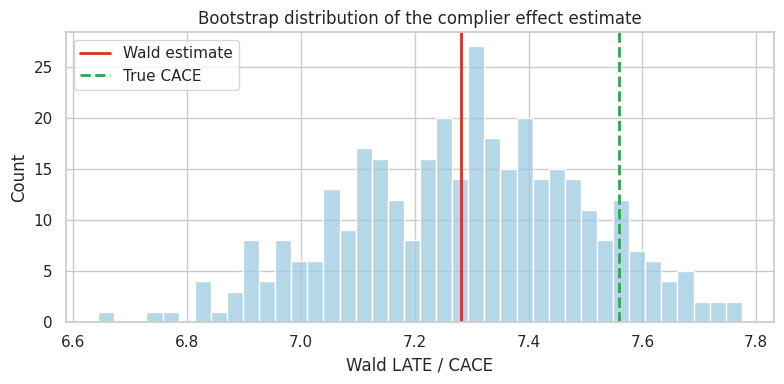

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(wald_boot, bins=40, color="#9ecae1", ax=ax)
ax.axvline(wald_late, color="#de2d26", linewidth=2, label="Wald estimate")
ax.axvline(true_cace, color="#31a354", linestyle="--", linewidth=2, label="True CACE")
ax.set_title("Bootstrap distribution of the complier effect estimate")
ax.set_xlabel("Wald LATE / CACE")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Principal Scores

A **principal score** is the probability that a unit belongs to a principal stratum conditional on pre-treatment covariates.

For noncompliance under monotonicity:

$$
P(\text{always-taker} \mid X) = P(D=1 \mid Z=0, X)
$$

$$
P(\text{complier} \mid X) = P(D=1 \mid Z=1, X) - P(D=1 \mid Z=0, X)
$$

$$
P(\text{never-taker} \mid X) = 1 - P(D=1 \mid Z=1, X)
$$

These are probabilities, not labels. They can help describe who the IV estimate is about.


In [12]:
control_received_model = smf.logit(
    "received ~ x + risk + age",
    data=df_nc.loc[df_nc["assignment"] == 0],
).fit(disp=False)

treatment_received_model = smf.logit(
    "received ~ x + risk + age",
    data=df_nc.loc[df_nc["assignment"] == 1],
).fit(disp=False)

score_data = df_nc[["x", "risk", "age"]].copy()
p_d0 = control_received_model.predict(score_data)
p_d1 = treatment_received_model.predict(score_data)

df_nc = df_nc.assign(
    ps_always=np.clip(p_d0, 0, 1),
    ps_complier=np.clip(p_d1 - p_d0, 0, 1),
    ps_never=np.clip(1 - p_d1, 0, 1),
)

principal_score_summary = (
    df_nc.groupby("stratum")[["ps_always", "ps_complier", "ps_never"]]
    .mean()
    .reindex(["Never-taker", "Complier", "Always-taker"])
)

principal_score_summary


,ps_always,ps_complier,ps_never
stratum,,,
Never-taker,0.119,0.542,0.339
Complier,0.180,0.579,0.241
Always-taker,0.253,0.571,0.175


This result should affect the next modeling or decision step. The useful readout is the causal contrast for a well-defined latent group, not a claim about observed take-up alone.

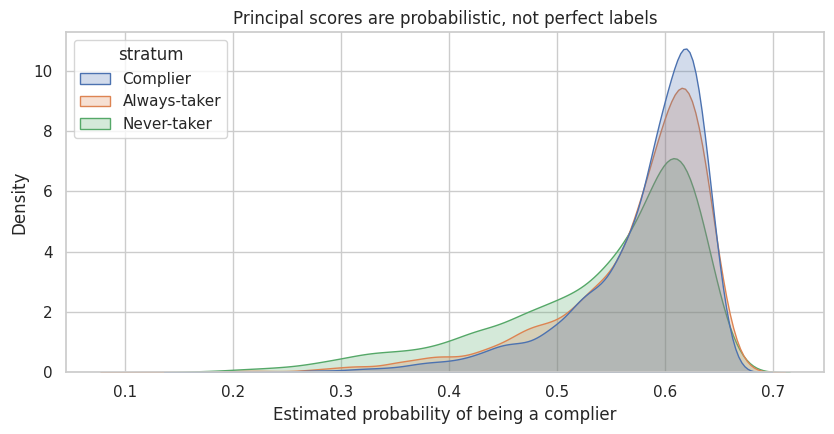

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.kdeplot(
    data=df_nc,
    x="ps_complier",
    hue="stratum",
    common_norm=False,
    fill=True,
    alpha=0.25,
    ax=ax,
)
ax.set_title("Principal scores are probabilistic, not perfect labels")
ax.set_xlabel("Estimated probability of being a complier")
plt.tight_layout()
plt.show()


Principal scores can support interpretation:

- Which covariate profiles contribute most to the complier estimand?
- Would a program expansion affect the same kinds of units?
- Is the LATE relevant to the decision population?

Principal scores are probabilistic summaries. Individual strata remain latent.


## 8. Example 2: Truncation by Death

Now consider an outcome that is only defined if a unit survives.

Examples:

- quality of life after medical treatment,
- employment outcomes after migration or displacement,
- test scores after staying enrolled,
- product satisfaction after remaining a customer.

If the outcome is undefined for non-survivors, it is not merely missing. Zhang and Rubin (2003) describe this as "truncation by death" and use principal stratification to define causal effects among units whose outcomes would be defined under both treatment assignments.


In [14]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_truncation_by_death(seed=44, n=12000):
    """Simulate the truncation by death data-generating process.
    
    Inputs:
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n`: number of simulated units or records to generate for the teaching example.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    severity = np.clip(rng.normal(0, 1, size=n), -2.5, 2.5)
    age = np.clip(rng.normal(62 + 5 * severity, 9, size=n), 30, 90)
    treatment = rng.binomial(1, 0.5, size=n)

    p_never = expit(-2.2 + 1.45 * severity + 0.025 * (age - 60))
    p_always = expit(0.65 - 1.10 * severity - 0.020 * (age - 60))
    raw_protected = np.clip(1 - p_never - p_always, 0.05, 0.95)
    probs = np.vstack([p_never, raw_protected, p_always]).T
    probs = probs / probs.sum(axis=1, keepdims=True)

    u = rng.uniform(size=n)
    cum = probs.cumsum(axis=1)
    stratum = np.where(u < cum[:, 0], "Never-survivor", np.where(u < cum[:, 1], "Protected", "Always-survivor"))

    s0 = np.where(stratum == "Always-survivor", 1, 0)
    s1 = np.where(stratum == "Never-survivor", 0, 1)
    survived = np.where(treatment == 1, s1, s0)

    base_qol = 55 - 5.0 * severity - 0.12 * (age - 60) + rng.normal(0, 6, size=n)
    sace_effect = 4.0 + 0.8 * (severity < 0)
    protected_qol_treated = 45 - 4.5 * severity - 0.16 * (age - 60) + rng.normal(0, 6, size=n)

    y0 = np.where(s0 == 1, base_qol, np.nan)
    y1 = np.where(
        s1 == 1,
        np.where(stratum == "Always-survivor", base_qol + sace_effect, protected_qol_treated),
        np.nan,
    )
    observed_y = np.where(treatment == 1, y1, y0)

    return pd.DataFrame(
        {
            "age": age,
            "severity": severity,
            "treatment": treatment,
            "stratum": stratum,
            "s0": s0,
            "s1": s1,
            "survived": survived,
            "y0": y0,
            "y1": y1,
            "qol": observed_y,
        }
    )


df_surv = simulate_truncation_by_death()
df_surv.head()


,age,severity,treatment,stratum,s0,s1,survived,y0,y1,qol
0,81.303,1.446,0,Never-survivor,0,0,0,NaN,NaN,NaN
1,63.088,0.102,1,Always-survivor,1,1,1,55.605,59.605,59.605
2,60.393,0.327,0,Always-survivor,1,1,1,53.545,57.545,53.545
3,90.000,1.136,1,Never-survivor,0,0,0,NaN,NaN,NaN
4,59.900,0.824,0,Always-survivor,1,1,1,42.635,46.635,42.635


The principal strata are:

- **always-survivors:** $S(0)=1, S(1)=1$,
- **protected:** $S(0)=0, S(1)=1$,
- **never-survivors:** $S(0)=0, S(1)=0$.

We assume monotonicity here: treatment does not prevent survival, so there are no harmed units with $S(0)=1, S(1)=0$.


In [15]:
survival_summary = (
    df_surv.groupby("treatment")
    .agg(
        n=("survived", "size"),
        survival_rate=("survived", "mean"),
        observed_qol_among_survivors=("qol", "mean"),
    )
    .rename(index={0: "Control", 1: "Treatment"})
)
survival_summary.loc["Difference"] = survival_summary.loc["Treatment"] - survival_summary.loc["Control"]
survival_summary


,n,survival_rate,observed_qol_among_survivors
treatment,,,
Control,"6,020.000",0.619,56.622
Treatment,"5,980.000",0.826,56.685
Difference,-40.000,0.206,0.063


The outcome comparison among observed survivors is tempting:

$$
E[Y \mid T=1, S=1] - E[Y \mid T=0, S=1]
$$

But under monotonicity:

- control survivors are always-survivors,
- treatment survivors are a mixture of always-survivors and protected units.

That is not a clean comparison of the same principal stratum.


In [16]:
observed_survivor_diff = (
    df_surv.loc[(df_surv["treatment"] == 1) & (df_surv["survived"] == 1), "qol"].mean()
    - df_surv.loc[(df_surv["treatment"] == 0) & (df_surv["survived"] == 1), "qol"].mean()
)

true_sace = (
    df_surv.loc[df_surv["stratum"] == "Always-survivor", "y1"].mean()
    - df_surv.loc[df_surv["stratum"] == "Always-survivor", "y0"].mean()
)

stratum_mix = pd.crosstab(
    [df_surv["treatment"], df_surv["survived"]],
    df_surv["stratum"],
    normalize="index",
).round(3)

pd.Series(
    {
        "Observed survivor comparison": observed_survivor_diff,
        "True survivor average causal effect": true_sace,
    }
), stratum_mix


(Observed survivor comparison          0.063
 True survivor average causal effect   4.521
 dtype: float64,
 stratum             Always-survivor  Never-survivor  Protected
 treatment survived                                            
 0         0                   0.000           0.467      0.533
           1                   1.000           0.000      0.000
 1         0                   0.000           1.000      0.000
           1                   0.748           0.000      0.252)

The survivor average causal effect is:

$$
SACE = E[Y(1) - Y(0) \mid S(1)=1, S(0)=1]
$$

It is about always-survivors. In real data, treatment-group survivors include protected units, so the always-survivor treatment mean is not directly observed.


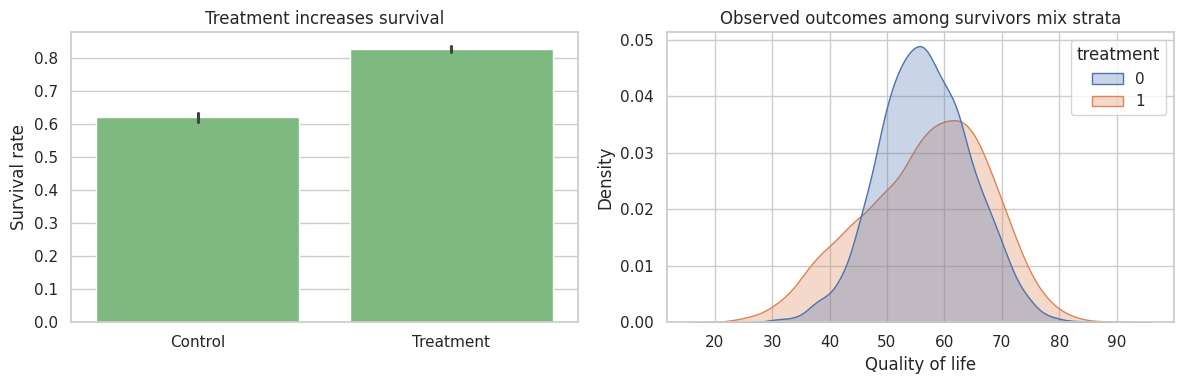

In [17]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=df_surv,
    x="treatment",
    y="survived",
    color="#74c476",
    ax=axes[0],
)
axes[0].set_title("Treatment increases survival")
axes[0].set_xticklabels(["Control", "Treatment"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Survival rate")

survivors = df_surv.loc[df_surv["survived"] == 1].copy()
sns.kdeplot(
    data=survivors,
    x="qol",
    hue="treatment",
    fill=True,
    common_norm=False,
    alpha=0.30,
    ax=axes[1],
)
axes[1].set_title("Observed outcomes among survivors mix strata")
axes[1].set_xlabel("Quality of life")

plt.tight_layout()
plt.show()


## 9. Bounds Under Monotonicity

Without identifying which treated survivors are always-survivors, we can bound the always-survivor treatment mean.

Under monotonicity:

$$
P(S(0)=1) = P(S=1 \mid T=0)
$$

$$
P(S(1)=1) = P(S=1 \mid T=1)
$$

Among treated survivors, the fraction who are always-survivors is:

$$
\frac{P(S(0)=1)}{P(S(1)=1)}
$$

If that fraction is $q$, then the always-survivor mean under treatment must lie between the mean of the lowest $q$ fraction and the highest $q$ fraction of treated survivor outcomes. This is a partial-identification argument, not a point estimate.


In [18]:
surv_control = df_surv.loc[df_surv["treatment"] == 0, "survived"].mean()
surv_treated = df_surv.loc[df_surv["treatment"] == 1, "survived"].mean()
q_always_among_treated_survivors = surv_control / surv_treated

treated_survivor_y = np.sort(
    df_surv.loc[(df_surv["treatment"] == 1) & (df_surv["survived"] == 1), "qol"].dropna().to_numpy()
)
n_keep = int(np.floor(q_always_among_treated_survivors * len(treated_survivor_y)))
lower_treated_mean = treated_survivor_y[:n_keep].mean()
upper_treated_mean = treated_survivor_y[-n_keep:].mean()
control_survivor_mean = df_surv.loc[(df_surv["treatment"] == 0) & (df_surv["survived"] == 1), "qol"].mean()

lee_bounds = pd.Series(
    {
        "Control survival rate": surv_control,
        "Treatment survival rate": surv_treated,
        "Always fraction among treated survivors": q_always_among_treated_survivors,
        "Lower bound for SACE": lower_treated_mean - control_survivor_mean,
        "Upper bound for SACE": upper_treated_mean - control_survivor_mean,
        "Observed survivor comparison": observed_survivor_diff,
        "True SACE in simulation": true_sace,
    }
)

lee_bounds


Control survival rate                      0.619
Treatment survival rate                    0.826
Always fraction among treated survivors    0.750
Lower bound for SACE                      -4.344
Upper bound for SACE                       5.083
Observed survivor comparison               0.063
True SACE in simulation                    4.521
dtype: float64

At this stage, trust comes from support, diagnostics, and a clear estimand. Principal strata help define effects for groups created by post-assignment behavior without conditioning naively on that behavior.

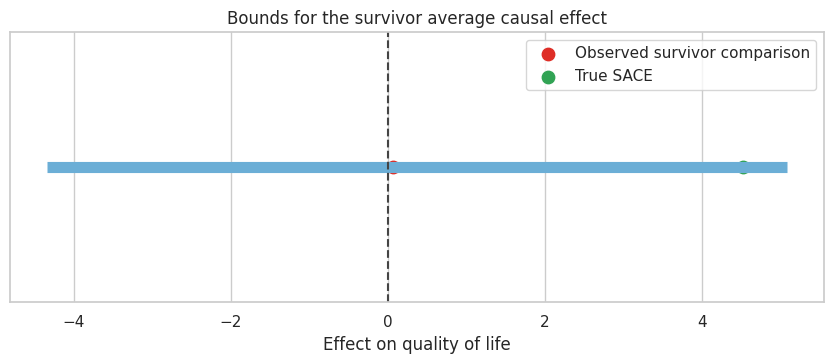

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.hlines(y=0, xmin=lee_bounds["Lower bound for SACE"], xmax=lee_bounds["Upper bound for SACE"], color="#6baed6", linewidth=8)
ax.scatter([observed_survivor_diff], [0], color="#de2d26", s=80, label="Observed survivor comparison")
ax.scatter([true_sace], [0], color="#31a354", s=80, label="True SACE")
ax.axvline(0, color="#444444", linestyle="--")
ax.set_yticks([])
ax.set_title("Bounds for the survivor average causal effect")
ax.set_xlabel("Effect on quality of life")
ax.legend()
plt.tight_layout()
plt.show()


The bounds can be wide. That is useful information. It tells the decision-maker that the data support a range of survivor-stratum effects unless additional assumptions are added.

latent strata help define effects for groups created by post-assignment behavior while avoiding naive conditioning on the observed post-treatment variable.

## 10. Principal Stratification Versus Ordinary Subgroups

Principal strata are not the same as observed subgroups.


| group_type | example | affected_by_treatment | causal_use |
|---|---|---|---|
| Pre-treatment subgroup | Age over 65, baseline risk, region | No | Can define ordinary subgroup ATEs. |
| Observed post-treatment subgroup | Received treatment, survived, engaged | Yes | Conditioning can create selection bias. |
| Principal stratum | Complier, always-survivor, protected | No, defined by joint potential values | Can define principal effects, but strata are latent. |


Principal stratification gives a clean estimand, not automatic identification. The usual workflow is:

1. define the post-treatment variable $S$,
2. define principal strata using $(S(0), S(1))$,
3. decide which stratum answers the scientific or business question,
4. state assumptions needed for identification or bounds,
5. estimate the principal effect or report partial identification.


## 11. Where Principal Stratification Shows Up in Industry

The language comes from statistics and biostatistics, but the pattern is common in industry.


| setting | post_treatment_variable | principal_question | risk_if_conditioning |
|---|---|---|---|
| Product onboarding | Activated in first 7 days | Effect among users who would activate only if onboarded? | Engaged treated users differ from engaged controls. |
| Marketplace incentives | Supplier accepts incentive | Effect among incentive-compliers? | Acceptors may be higher motivation or lower opportunity cost. |
| Health program | Survives to outcome measurement | Effect among always-survivors? | Treatment survivors include units saved by treatment. |
| Education intervention | Remains enrolled | Effect among students who would remain enrolled either way? | Treatment can change who remains observed. |
| AI assistant deployment | Uses suggested workflow | Effect among users whose workflow adoption is induced? | Observed adopters are selected after treatment exposure. |


## 12. Reporting Template

A principal-stratification readout should be explicit about the latent stratum and the assumptions.


| section | what_to_report |
|---|---|
| Post-treatment variable | Define S and why ordinary conditioning on observed S is problematic. |
| Principal strata | List possible values of (S(0), S(1)) and name the target stratum. |
| Estimand | State the principal effect, such as CACE or SACE. |
| Identification | State randomization, exclusion, monotonicity, principal ignorability, or bounding assumptions. |
| Observed evidence | Show first stage, ITT, observed subgroup comparisons, and why they differ. |
| Uncertainty | Report confidence intervals, bootstrap intervals, or partial-identification bounds. |
| Decision relevance | Explain whether the principal stratum maps to the decision population. |


## 13. Decision Memo Example

Principal stratification can feel abstract. The memo should translate the estimand into plain language without hiding assumptions.


In [23]:
memo = f'''
### Principal Stratification Readout: Encouragement With Noncompliance

**Decision question:** should the organization continue an encouragement program when not everyone follows assignment?

**Post-treatment variable:** actual treatment receipt. Conditioning directly on receipt is not a valid causal subgroup comparison because receipt is affected by assignment and by latent compliance type.

**Principal stratum of interest:** compliers, defined as units who would receive treatment if assigned treatment and would not receive it if assigned control.

**Estimand:** complier average causal effect.

**Evidence:** the assignment increased treatment receipt by **{first_stage:,.3f}** and changed the outcome by **{itt_y:,.3f}**. The Wald estimate is **{wald_late:,.2f}**, with a bootstrap 95% interval from **{wald_summary["ci_lower"]:,.2f}** to **{wald_summary["ci_upper"]:,.2f}**.

**Interpretation:** under random assignment, exclusion, and monotonicity, this estimates the effect for compliers. It is not the average effect for always-takers, never-takers, or the entire eligible population.

**Recommendation:** use the estimate if the policy decision concerns people whose treatment receipt can be shifted by the encouragement. If the decision is about mandatory treatment or broad access, collect additional evidence because the complier effect may not transport to other strata.
'''

display(Markdown(memo))



### Principal Stratification Readout: Encouragement With Noncompliance

**Decision question:** should the organization continue an encouragement program when not everyone follows assignment?

**Post-treatment variable:** actual treatment receipt. Conditioning directly on receipt is not a valid causal subgroup comparison because receipt is affected by assignment and by latent compliance type.

**Principal stratum of interest:** compliers, defined as units who would receive treatment if assigned treatment and would not receive it if assigned control.

**Estimand:** complier average causal effect.

**Evidence:** the assignment increased treatment receipt by **0.567** and changed the outcome by **4.130**. The Wald estimate is **7.28**, with a bootstrap 95% interval from **6.89** to **7.67**.

**Interpretation:** under random assignment, exclusion, and monotonicity, this estimates the effect for compliers. It is not the average effect for always-takers, never-takers, or the entire eligible population.

**Recommendation:** use the estimate if the policy decision concerns people whose treatment receipt can be shifted by the encouragement. If the decision is about mandatory treatment or broad access, collect additional evidence because the complier effect may not transport to other strata.


## 14. Common Failure Modes

- **Conditioning on observed post-treatment variables** and calling the result causal.
- **Interpreting LATE as the population ATE.**
- **Forgetting exclusion restrictions** in noncompliance settings.
- **Assuming monotonicity without subject-matter justification.**
- **Treating truncated outcomes as merely missing.**
- **Reporting point estimates when only bounds are credible.**
- **Using principal scores as if they perfectly classify individuals.**
- **Choosing a principal stratum after seeing results; strata should be planned before analysis.**


## 15. Exercises

1. In the noncompliance simulation, add defiers. How does the Wald estimate relate to the true complier effect?
2. Change always-takers so they have very large treatment effects. Does the Wald estimate change? Why or why not?
3. Add a direct effect of assignment on outcome that does not operate through treatment received. What happens to the IV interpretation?
4. In the truncation-by-death simulation, make treatment harmful for some units so monotonicity fails. What happens to the bounds logic?
5. Use severity and age to model the probability of being an always-survivor. How well can you separate strata?
6. Write a principal-stratification estimand for a product feature where the post-treatment variable is "used the feature at least once."


## 16. Key Takeaways

- Principal stratification handles causal questions involving post-treatment variables.
- Principal strata are defined by joint potential values, such as $(D(0),D(1))$ or $(S(0),S(1))$.
- Observed post-treatment groups are usually mixtures of principal strata.
- Noncompliance leads naturally to compliers, always-takers, never-takers, and defiers.
- Under standard IV assumptions, the Wald estimand identifies the complier average causal effect.
- Truncation by death requires care because outcomes for non-survivors are undefined, not just missing.
- Principal stratification clarifies estimands, but identification still depends on assumptions or bounds.


## References

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. [https://doi.org/10.1080/01621459.1996.10476902](https://doi.org/10.1080/01621459.1996.10476902)

Ding, P., Geng, Z., Yan, W., & Zhou, X.-H. (2011). Identifiability and estimation of causal effects by principal stratification with outcomes truncated by death. *Journal of the American Statistical Association, 106*(496), 1578-1591. [https://doi.org/10.1198/jasa.2011.tm10265](https://doi.org/10.1198/jasa.2011.tm10265)

Frangakis, C. E., & Rubin, D. B. (2002). Principal stratification in causal inference. *Biometrics, 58*(1), 21-29. [https://doi.org/10.1111/j.0006-341X.2002.00021.x](https://doi.org/10.1111/j.0006-341X.2002.00021.x)

Zhang, J. L., & Rubin, D. B. (2003). Estimation of causal effects via principal stratification when some outcomes are truncated by death. *Journal of Educational and Behavioral Statistics, 28*(4), 353-368. [https://doi.org/10.3102/10769986028004353](https://doi.org/10.3102/10769986028004353)
